In [137]:
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm
from matplotlib.image import imread

from adj import main, combine_graph_dict
from train import train_model
from utils import mclust_R, fix_seed

In [138]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score
from sklearn.metrics import v_measure_score as v_score
from utils import compute_PAS, compute_CHAOS
from sklearn.decomposition import PCA

In [139]:
fix_seed(1)

In [140]:
count = pd.read_csv("../data/HumanHeart/Developmental_heart/Filtered/filtered_ST_matrix_and_meta_data/filtered_ST_matrix_and_meta_data/filtered_matrix.tsv",
                    sep="\t", index_col=0).T
count

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.10,ENSG00000001167.14,...,ENSG00000283667.1,ENSG00000283669.1,ENSG00000283674.1,ENSG00000283675.1,ENSG00000283683.1,ENSG00000283684.1,ENSG00000283689.1,ENSG00000283692.1,ENSG00000283696.1,ENSG00000283698.1
1x17x20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1x17x21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1x17x22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1x18x18,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1x18x19,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19x9x11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19x9x12,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19x9x13,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19x9x8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [141]:
meta = pd.read_csv("../data/HumanHeart/Developmental_heart/Filtered/filtered_ST_matrix_and_meta_data/filtered_ST_matrix_and_meta_data/meta_data.tsv",
                   sep="\t", index_col=0)
meta

,nGene,nUMI,Sample,weeks,ChipBatch,ChipNr,Experiment_date,Experiment_procedure,Sequencing_date,Raw_reads,new_x,new_y,percent.mito,res.0.8
1x17x20,666,1046,FH5_1000L3_CN20_C1,5,1000L3,CN20,151105,manual,151117,35432474,16.92,19.99,0.018164,0
1x17x21,891,1361,FH5_1000L3_CN20_C1,5,1000L3,CN20,151105,manual,151117,35432474,17.06,20.95,0.007348,2
1x17x22,1138,1878,FH5_1000L3_CN20_C1,5,1000L3,CN20,151105,manual,151117,35432474,17.02,22.02,0.007455,0
1x18x18,766,1170,FH5_1000L3_CN20_C1,5,1000L3,CN20,151105,manual,151117,35432474,17.99,18.00,0.021368,4
1x18x19,536,820,FH5_1000L3_CN20_C1,5,1000L3,CN20,151105,manual,151117,35432474,17.95,18.99,0.014634,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19x9x11,1133,2330,FH9_1000L3_CN31_E2,9,1000L3,CN31,151105,manual,160111,83186609,8.92,11.08,0.019313,3
19x9x12,865,1599,FH9_1000L3_CN31_E2,9,1000L3,CN31,151105,manual,160111,83186609,8.98,12.01,0.023139,0
19x9x13,1265,2897,FH9_1000L3_CN31_E2,9,1000L3,CN31,151105,manual,160111,83186609,8.88,13.01,0.018985,1
19x9x8,1343,2594,FH9_1000L3_CN31_E2,9,1000L3,CN31,151105,manual,160111,83186609,8.95,8.02,0.014649,3


In [142]:
batch_list = list(meta['Sample'].unique())
batch_list

['FH5_1000L3_CN20_C1',
 'FH5_1000L3_CN20_C2',
 'FH5_1000L3_CN20_D1',
 'FH5_1000L3_CN20_D2',
 'FH6_1000L2_CN73_E1',
 'FH6_1000L2_CN73_E2',
 'FH6_1000L2_CN73_D2',
 'FH6_1000L2_CN73_C2',
 'FH6_1000L2_CN74_E1',
 'FH6_1000L2_CN74_E2',
 'FH6_1000L2_CN74_D1',
 'FH6_1000L2_CN74_D2',
 'FH6_1000L2_CN74_C1',
 'FH9_1000L3_CN31_C1',
 'FH9_1000L3_CN31_C2',
 'FH9_1000L3_CN31_D1',
 'FH9_1000L3_CN31_D2',
 'FH9_1000L3_CN31_E1',
 'FH9_1000L3_CN31_E2']

In [143]:
sample_count = meta['Sample'].value_counts()
sample_count

Sample
FH9_1000L3_CN31_D1    243
FH9_1000L3_CN31_C2    242
FH9_1000L3_CN31_C1    238
FH9_1000L3_CN31_D2    226
FH6_1000L2_CN74_E1    214
FH9_1000L3_CN31_E2    211
FH6_1000L2_CN74_E2    209
FH9_1000L3_CN31_E1    198
FH6_1000L2_CN73_C2    186
FH6_1000L2_CN74_D2    182
FH6_1000L2_CN74_C1    180
FH6_1000L2_CN74_D1    178
FH6_1000L2_CN73_D2    159
FH6_1000L2_CN73_E2    104
FH6_1000L2_CN73_E1    103
FH5_1000L3_CN20_D1     69
FH5_1000L3_CN20_C2     59
FH5_1000L3_CN20_D2     55
FH5_1000L3_CN20_C1     55
Name: count, dtype: int64

In [144]:
genes_new = pd.read_csv("../data/HumanHeart/Developmental_heart/Filtered/filtered_ST_matrix_and_meta_data/filtered_ST_matrix_and_meta_data/genes_new.txt")
genes_new

,x
0,TSPAN6
1,TNMD
2,DPM1
3,SCYL3
4,C1orf112
...,...
39734,AC013268.5
39735,AC018553.2
39736,Z96074.1
39737,AL592295.4


In [145]:
count.columns = list(genes_new.x.values)

In [146]:
count = count.loc[:, count.columns.notna()]

In [147]:
#count.head()

In [148]:
adata_st_list_raw = []

#str(i+4)跳过了前四个切片
for i in range(1, 10):
    count_i = count[[loc.split("x")[0]==str(i+4) for loc in count.index]]
    count_i.index = [(loc.split("x")[1]+"x"+loc.split("x")[2]) for loc in count_i.index]
    meta_i = meta[[loc.split("x")[0]==str(i+4) for loc in meta.index]]
    meta_i.index = [(loc.split("x")[1]+"x"+loc.split("x")[2]) for loc in meta_i.index]

    loc_i = pd.read_csv("../data/HumanHeart/ST_Samples_6.5PCW/ST_Sample_6.5PCW_%d/spot_data-all-ST_Sample_6.5PCW_%d.tsv" % (i, i),
                       sep="\t")
    # loc_i = pd.read_csv("./data/ST_Samples_6.5PCW/ST_Sample_6.5PCW_%d/spot_data-all-ST_Sample_6.5PCW_%d.tsv" % (i, i),
    #                    sep="\t")

    loc_i.index = [(str(loc_i.x.values[k]) + 'x' + str(loc_i.y.values[k])) for k in range(loc_i.shape[0])]
    loc_i = loc_i.loc[meta_i.index]

    img_i = imread('../data/HumanHeart/ST_Samples_6.5PCW/ST_Sample_6.5PCW_%d/ST_Sample_6.5PCW_%d_HE_small.jpg' % (i, i))

    adata_st_i = ad.AnnData(X = count_i.values)

    adata_st_i.obs = meta_i
    adata_st_i.obs['selected'] = loc_i['selected'].values
    adata_st_i.var.index = count_i.columns

    library_id = '0'
    adata_st_i.uns["spatial"] = dict()
    adata_st_i.uns["spatial"]['0'] = dict()
    adata_st_i.uns["spatial"]['0']['images'] = dict()
    adata_st_i.uns["spatial"]['0']['images']['hires'] = img_i
    adata_st_i.uns["spatial"]['0']['scalefactors'] = {'spot_diameter_fullres': 100,
                                                      'tissue_hires_scalef': 1.0,
                                                      'fiducial_diameter_fullres': 100,
                                                      'tissue_lowres_scalef': 1.0}

    adata_st_i.obsm['spatial'] = np.concatenate((loc_i['pixel_x'].values.reshape(-1, 1),
                                                 loc_i['pixel_y'].values.reshape(-1, 1)), axis=1)

    adata_st_i.obsm['loc_use'] = np.concatenate((loc_i['x'].values.reshape(-1, 1),
                                                 loc_i['y'].values.reshape(-1, 1)), axis=1)

    adata_st_i.obs['array_row'] = loc_i['y'].values
    adata_st_i.obs['array_col'] = loc_i['x'].values

    adata_st_i = adata_st_i[adata_st_i.obs['selected'].values != 0]
    adata_st_list_raw.append(adata_st_i.copy())

In [149]:
adata_st_list_raw

[AnnData object with n_obs × n_vars = 100 × 39525
     obs: 'nGene', 'nUMI', 'Sample', 'weeks', 'ChipBatch', 'ChipNr', 'Experiment_date', 'Experiment_procedure', 'Sequencing_date', 'Raw_reads', 'new_x', 'new_y', 'percent.mito', 'res.0.8', 'selected', 'array_row', 'array_col'
     uns: 'spatial'
     obsm: 'spatial', 'loc_use',
 AnnData object with n_obs × n_vars = 101 × 39525
     obs: 'nGene', 'nUMI', 'Sample', 'weeks', 'ChipBatch', 'ChipNr', 'Experiment_date', 'Experiment_procedure', 'Sequencing_date', 'Raw_reads', 'new_x', 'new_y', 'percent.mito', 'res.0.8', 'selected', 'array_row', 'array_col'
     uns: 'spatial'
     obsm: 'spatial', 'loc_use',
 AnnData object with n_obs × n_vars = 155 × 39525
     obs: 'nGene', 'nUMI', 'Sample', 'weeks', 'ChipBatch', 'ChipNr', 'Experiment_date', 'Experiment_procedure', 'Sequencing_date', 'Raw_reads', 'new_x', 'new_y', 'percent.mito', 'res.0.8', 'selected', 'array_row', 'array_col'
     uns: 'spatial'
     obsm: 'spatial', 'loc_use',
 AnnData obje

In [150]:
num = 0
for i in range(len(adata_st_list_raw)):
    num_tmp = len(adata_st_list_raw[i].obs)
    num = num + num_tmp
num

1480

In [151]:
slice_use = []
for i in range(9):
    slice_name = adata_st_list_raw[i].obs['Sample'][0]
    slice_use.append(slice_name)
slice_use

['FH6_1000L2_CN73_E1',
 'FH6_1000L2_CN73_E2',
 'FH6_1000L2_CN73_D2',
 'FH6_1000L2_CN73_C2',
 'FH6_1000L2_CN74_E1',
 'FH6_1000L2_CN74_E2',
 'FH6_1000L2_CN74_D1',
 'FH6_1000L2_CN74_D2',
 'FH6_1000L2_CN74_C1']

In [16]:
def mapping2int(string_array):
    mapping = {}
    result = []
    for string in string_array:
        if string not in mapping:
            mapping[string] = len(mapping)
        result.append(mapping[string])
    return result, mapping

result, mapping = mapping2int(slice_use)

In [17]:
for i, proj_name in enumerate(slice_use):
    adata_tmp = adata_st_list_raw[i]
    adata_tmp.var_names_make_unique()

    adata_tmp.obs['batch_name'] = proj_name
    graph_dict_tmp = main(adata_tmp, adj_cons_by='coordinate', distType='KNN', k_cutoff=8, rad_cutoff=250)
    
    ##### Load layer_guess label, if have
    # df_label = pd.read_csv(data_root / proj_name / 'manual_annotations.txt', sep='\t', header=None, index_col=0)
    # df_label.columns = ['layer_guess']
    # adata_tmp.obs['layer_guess'] = df_label['layer_guess']
    #adata_tmp= adata_tmp[~pd.isnull(adata_tmp.obs['layer_guess'])]
    
    if proj_name == slice_use[0]:
        adata = adata_tmp
        graph_dict = graph_dict_tmp
        name = proj_name
        adata.obs['proj_name'] = proj_name
        # adata.uns["spatial"] = dict()
        # adata.uns["spatial"][proj_name] = adata_tmp.uns["spatial"]  # 将当前切片的空间信息保留在新对象中
    else:
        var_names = adata.var_names.intersection(adata_tmp.var_names)
        adata = adata[:, var_names]
        adata_tmp = adata_tmp[:, var_names]
        adata_tmp.obs['proj_name'] = proj_name
    
        adata = adata.concatenate(adata_tmp)
        graph_dict = combine_graph_dict(graph_dict, graph_dict_tmp)
        # adata.uns["spatial"][proj_name] = adata_tmp.uns["spatial"]
        name = name + '_' + proj_name

------Calculating spatial graph...
The graph contains 800 edges, 100 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 808 edges, 101 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1240 edges, 155 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1456 edges, 182 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1696 edges, 212 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1624 edges, 203 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1384 edges, 173 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1440 edges, 180 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1392 edges, 174 cells.
8.000

In [18]:
adata

AnnData object with n_obs × n_vars = 1480 × 39525
    obs: 'nGene', 'nUMI', 'Sample', 'weeks', 'ChipBatch', 'ChipNr', 'Experiment_date', 'Experiment_procedure', 'Sequencing_date', 'Raw_reads', 'new_x', 'new_y', 'percent.mito', 'res.0.8', 'selected', 'array_row', 'array_col', 'batch_name', 'proj_name', 'batch'
    obsm: 'spatial', 'loc_use'

In [19]:
adata.layers['count'] = adata.X
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=3000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

In [20]:
SpaBatch_net = train_model(adata, graph_dict, pre_epochs=800 ,epochs=1000, mask_rate=0.2)
using_dec = True
if using_dec:
    SpaBatch_net.train_with_dec(num_aggre=1)
else:
    SpaBatch_net.train_without_dec()

Epoch 799 total loss=15.690: 100%|██████████ [ time left: 00:00 ]    
Epoch 999 total loss=9.197 recon loss=8.036 kl loss=0.051 tri loss=0.649 : |           [ time left: 00:00 ]      


In [21]:
SpaBatch_feat, _ = SpaBatch_net.process()
adata.obsm['SpaBatch'] = SpaBatch_feat

In [22]:
mclust_R(adata, num_cluster=6, used_obsm='SpaBatch')

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 1480 × 3000
    obs: 'nGene', 'nUMI', 'Sample', 'weeks', 'ChipBatch', 'ChipNr', 'Experiment_date', 'Experiment_procedure', 'Sequencing_date', 'Raw_reads', 'new_x', 'new_y', 'percent.mito', 'res.0.8', 'selected', 'array_row', 'array_col', 'batch_name', 'proj_name', 'batch', 'mclust'
    var: 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg'
    obsm: 'spatial', 'loc_use', 'X_pca', 'Tri_SEDR', 'SEDR'
    layers: 'count'

In [23]:
adata.write("HH2.h5ad")

In [24]:
# sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
# ARI = ari_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
# print(f"total ARI:{ARI}")
# for name in proj_list:
#     sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
#     ARI = ari_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
#     print(f"{name} ARI:{ARI}")

In [25]:
# sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
# NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
# print(f"total NMI:{NMI}")
# AMI = ami_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
# print(f"total AMI:{AMI}")
# for name in proj_list:
#     sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
#     NMI = nmi_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
#     AMI = ami_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
#     ACC = 1/2 * (NMI + AMI)
#     print(f"{name} ACC:{ACC}")

In [26]:
# sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
# HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
# print(f"total HOM:{HOM}")
# COM = com_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
# print(f"total COM:{COM}")
# for name in proj_list:
#     sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
#     HOM = hom_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
#     COM = com_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
#     V =  2 * ((HOM * COM) / (HOM + COM))
#     print(f"{name} V:{V}")

3.63698300196287


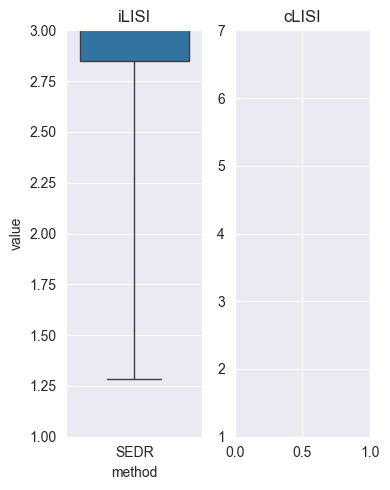

In [27]:
import harmonypy as hm

iLISI = hm.compute_lisi(adata.obsm['SpaBatch'], adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
#cLISI = hm.compute_lisi(adata.obsm['SpaBatch'], adata.obs[['annotation']], label_colnames=['annotation'])[:, 0]
df_iLISI = pd.DataFrame({
    'method': 'SpaBatch',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

# df_cLISI = pd.DataFrame({
#     'method': 'SpaBatch',
#     'value': cLISI,
#     'type': ['CLISI'] * len(cLISI)
# })

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
# sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
# print(np.median(cLISI))

In [4]:
custom_palette1 = {
    1: '#1f77b4',  
    2: '#ff7f0e',  
    3: '#2ca02c',  
    4: '#d62728',  
    5: '#9467bd',  
    6: '#8c564b',  
    7: '#e377c2',  
    8: '#7f7f7f',  
    9: '#bcbd22',  
    10: '#17becf'
}

custom_palette11 = {
    1: '#1f77b4',  
    2: '#2ca02c',
    3: '#ff7f0e',  
    4: '#d62728',  
    5: '#9467bd',  
    6: '#8c564b',  
    7: '#e377c2',  
    8: '#7f7f7f',  
    9: '#bcbd22',  
    10: '#17becf'
}

custom_palette2 = {
    1: '#2e2c83',  
    2: '#7aa5db',  
    3: '#40a8a7',  
    4: '#3278ae',  
    5: '#11743b',  
    6: '#a74197',  
    7: '#f7a11b',  
    8: '#d7a577',  
    9: '#959b2e',  
    10: '#000000'
}

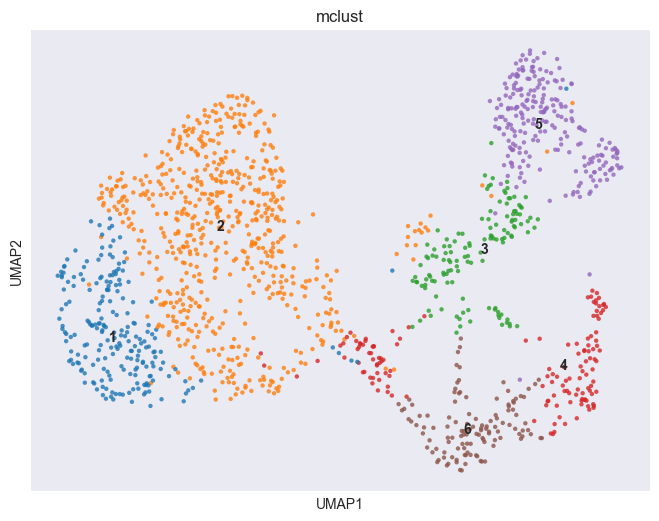

In [5]:
import scanpy as sc
import matplotlib.pyplot as plt

# Step 1: 计算邻居图和 UMAP
sc.pp.neighbors(adata, use_rep='SpaBatch', metric='cosine', n_neighbors=15)  # 可调整 n_neighbors
sc.tl.umap(adata, min_dist=0.5)  # 调整 min_dist 参数优化聚类

fig, ax = plt.subplots(figsize=(8, 6))  # 创建自定义图形和坐标轴对象
# Step 2: 绘制 UMAP
sc.pl.umap(
    adata, 
    color=['mclust'], 
    size=40,  # 调整点大小
    alpha=0.8,  # 调整透明度
    palette=custom_palette1,  # 自定义调色板
    legend_loc='on data',
    ax=ax
)

ax.set_xlabel('UMAP1')  # 设置 x 轴标签
ax.set_ylabel('UMAP2')  # 设置 y 轴标签
ax.grid(True, linestyle='--', alpha=0.5)  # 添加网格线
# # Step 3: 保存高分辨率图片
# output_path = "results/optimized_umap.png"
# plt.savefig(output_path, dpi=300, bbox_inches='tight')  # 高分辨率保存



   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.10, Tutorials: https://omicverse.readthedocs.io/
Dependency error: The 'bioservices' distribution was not found and is required by the application


<AxesSubplot: xlabel='X_umap1', ylabel='X_umap2'>

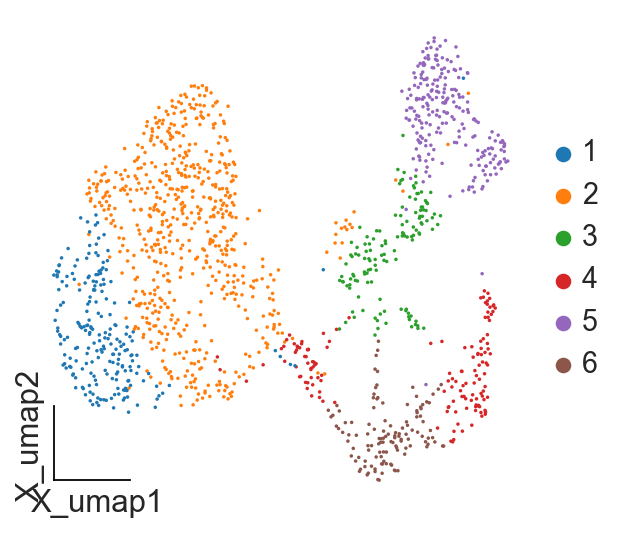

In [31]:
import omicverse as ov
ov.ov_plot_set()

fig, ax=plt.subplots(figsize=(4,4))
ov.pl.embedding(adata,
                basis="X_umap",
                color=['mclust'],
                title='',
                show=False,
                size=10,
                frameon='small',
                ax=ax
                )

In [32]:
# sc.tl.tsne(adata)
# sc.pl.tsne(adata, color=['mclust'], show=True, save=False)

In [33]:
# import matplotlib.pyplot as plt
# 
# # color = ['#7570b3', '#1b9e77', '#d95f02', '#66a61e', '#e7298a']
# 
# spot_size = 70
# for slice_id, slice_name in enumerate(slice_use):
#     # print(slice_id)
#     # print(slice_name)
#     adata_st_list_raw_tmp = adata_st_list_raw[slice_id]
#     # print(adata_st_list_raw_tmp)
#     adata_tmp = adata[adata.obs['batch_name'] == slice_use[slice_id]]
#     adata_tmp.uns['spatial'] = adata_st_list_raw_tmp.uns['spatial']
#     # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
#     sc.pl.spatial(adata_tmp, img_key="hires", color=["mclust"], palette=custom_palette2, size=1.5, title=f"Slice_{slice_name}")
#     # plt.savefig(f'result/{slice_name}', dpi=300)
# plt.tight_layout()

In [152]:
adata = sc.read_h5ad('HH2.h5ad')

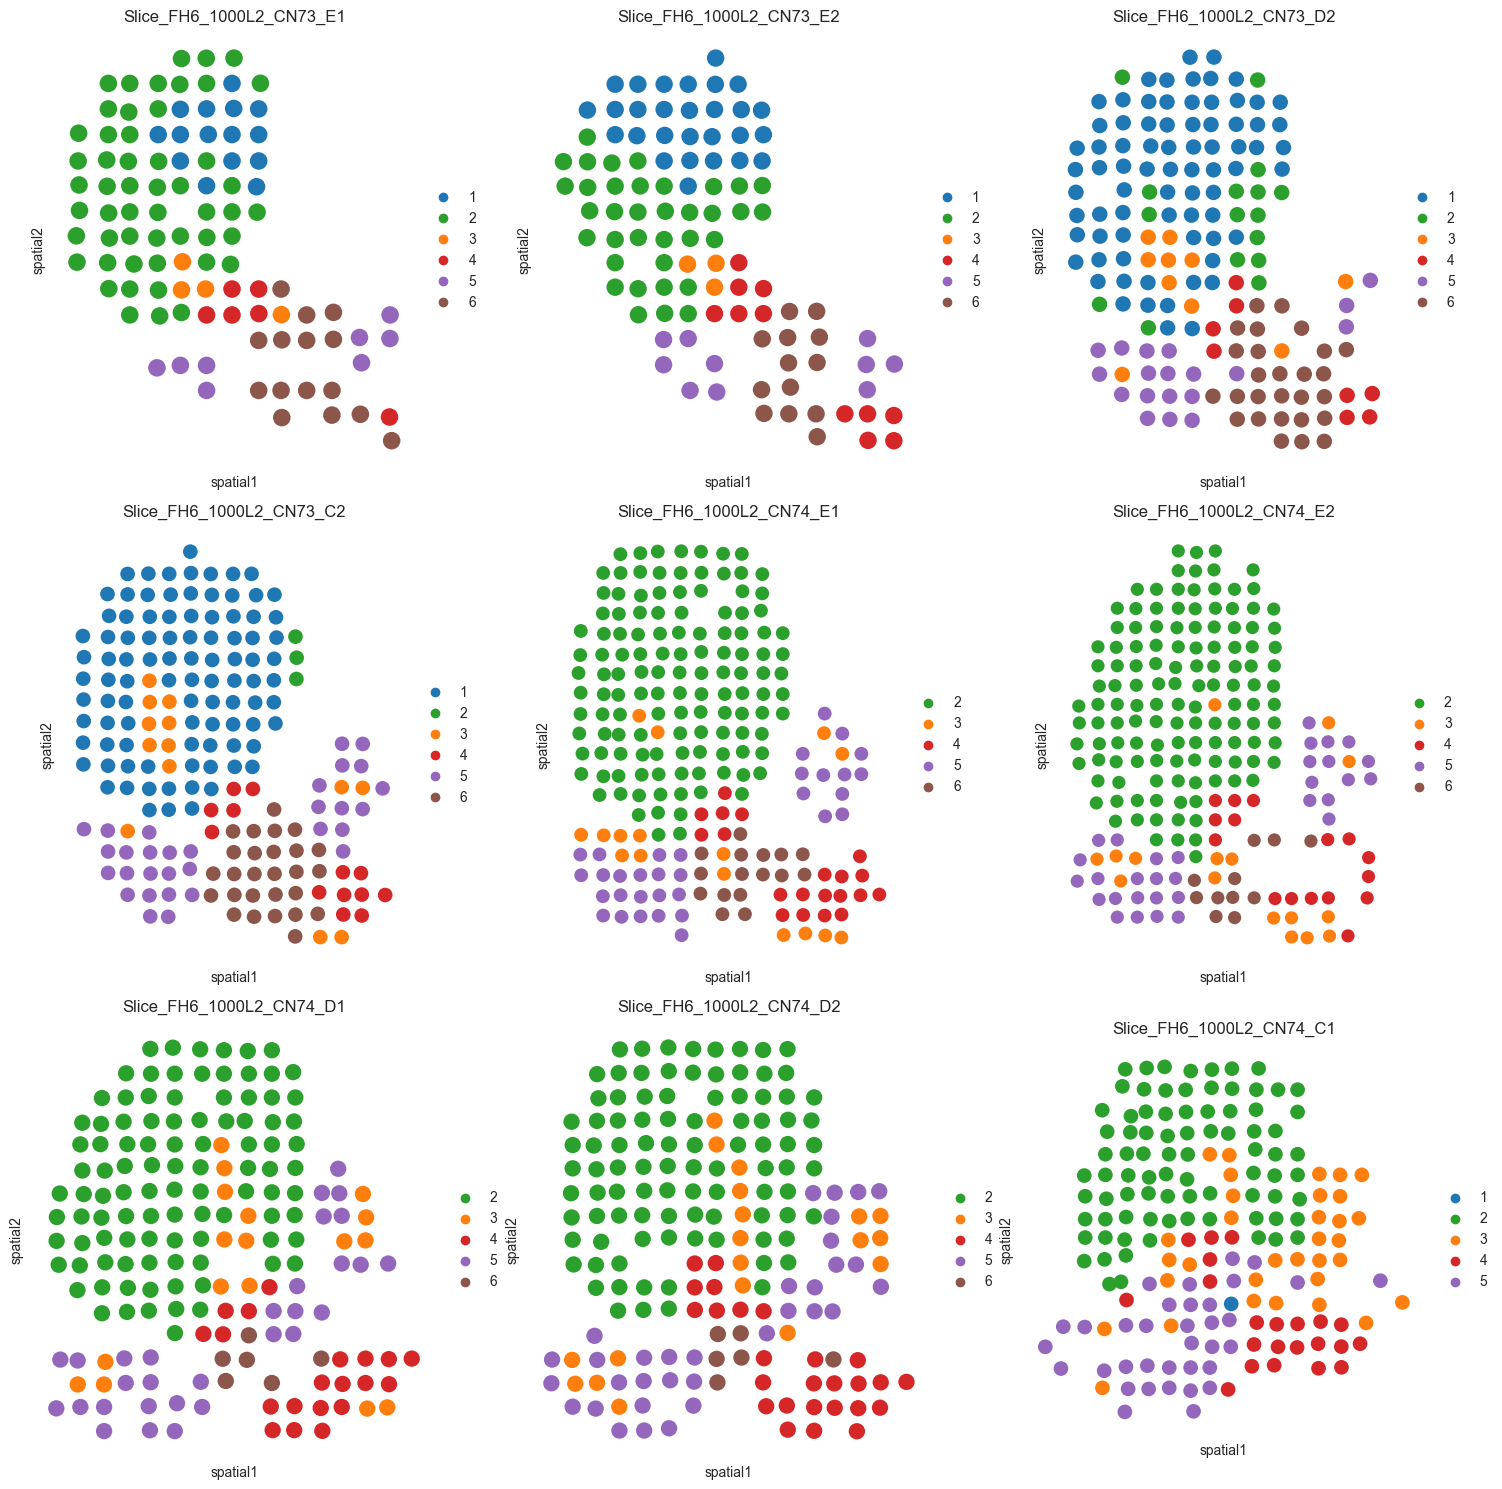

In [153]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # 调整图大小

for slice_id, (slice_name, ax) in enumerate(zip(slice_use, axes.flatten())):
    # 获取当前切片数据
    adata_st_list_raw_tmp = adata_st_list_raw[slice_id]
    adata_tmp = adata[adata.obs['batch_name'] == slice_use[slice_id]]
    adata_tmp.uns['spatial'] = adata_st_list_raw_tmp.uns['spatial']
    
    # 绘制空间图
    sc.pl.spatial(
        adata_tmp,
        img_key=None,
        color=["mclust"],
        palette=custom_palette11,
        size=1.5,
        title=f"Slice_{slice_name}",
        ax=ax,  # 指定子图
        show=False,  # 不显示图像
    )

# 如果总子图数多于切片数，隐藏多余的子图
# for ax in axes.flatten()[num_slices:]:
#     ax.axis('off')

# 调整子图布局并保存图像
plt.tight_layout()
#plt.savefig("combined_slices.png", dpi=300)  # 保存图片
plt.show()  # 显示图像

In [ ]:
#差析差异

In [154]:
adata.obs['mclust'] = adata.obs['mclust'].astype(str)

In [171]:
sc.tl.rank_genes_groups(adata, 'mclust', groups=['1'], reference='2', key_added = "1vs2")

In [172]:
cut_log2fc_min = 2

g_list1 = list(sc.get.rank_genes_groups_df(adata, group=['1'], key='1vs2', pval_cutoff=0.05, log2fc_min=cut_log2fc_min)['names'])
g_list1_filter = g_list1[0:30]

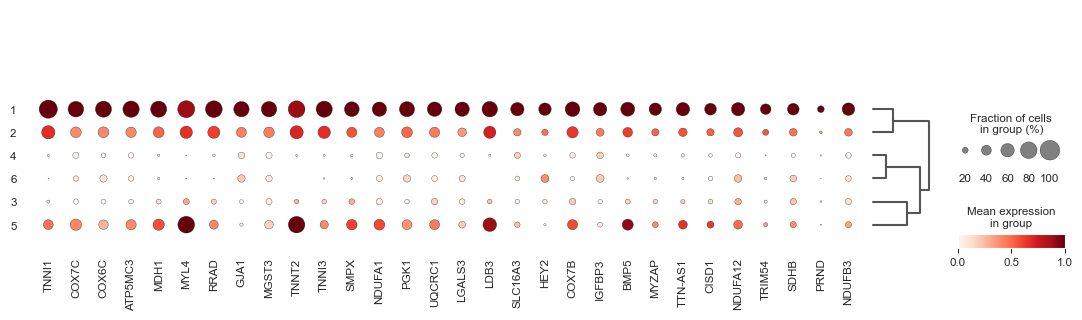

In [173]:
sc.pl.dotplot(adata, g_list1_filter, groupby='mclust', dendrogram=True, swap_axes=False, standard_scale='var', )

In [174]:
#富集
import gseapy

enr_res1 = gseapy.enrichr(gene_list=g_list1,
                         organism='Mouse',
                         gene_sets='GO_Biological_Process_2023',
                         cutoff=0.5)
enr_res1.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Mitochondrial ATP Synthesis Coupled Electron T...,8/70,9.323417e-11,5.510140e-08,0,0,42.731183,986.915415,COX7B;NDUFA12;NDUFB3;UQCRC1;NDUFA1;COX6C;SDHB;...
1,GO_Biological_Process_2023,Cellular Respiration (GO:0045333),8/85,4.566177e-10,1.349305e-07,0,0,34.380952,739.437143,COX7B;NDUFA12;NDUFB3;UQCRC1;NDUFA1;COX6C;SDHB;...
2,GO_Biological_Process_2023,Aerobic Electron Transport Chain (GO:0019646),7/68,3.146435e-09,6.198478e-07,0,0,37.381618,731.819771,COX7B;NDUFB3;UQCRC1;NDUFA1;COX6C;COX7C;SDHB
3,GO_Biological_Process_2023,Energy Derivation By Oxidation Of Organic Comp...,5/43,3.406625e-07,5.033289e-05,0,0,41.549708,618.773766,COX7B;UQCRC1;COX6C;COX7C;MT3
4,GO_Biological_Process_2023,Striated Muscle Contraction (GO:0006941),5/57,1.428368e-06,1.560669e-04,0,0,30.341880,408.370693,MYL4;SMPX;TNNT2;TNNI1;TNNI3


<Axes: title={'center': '1vs2'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

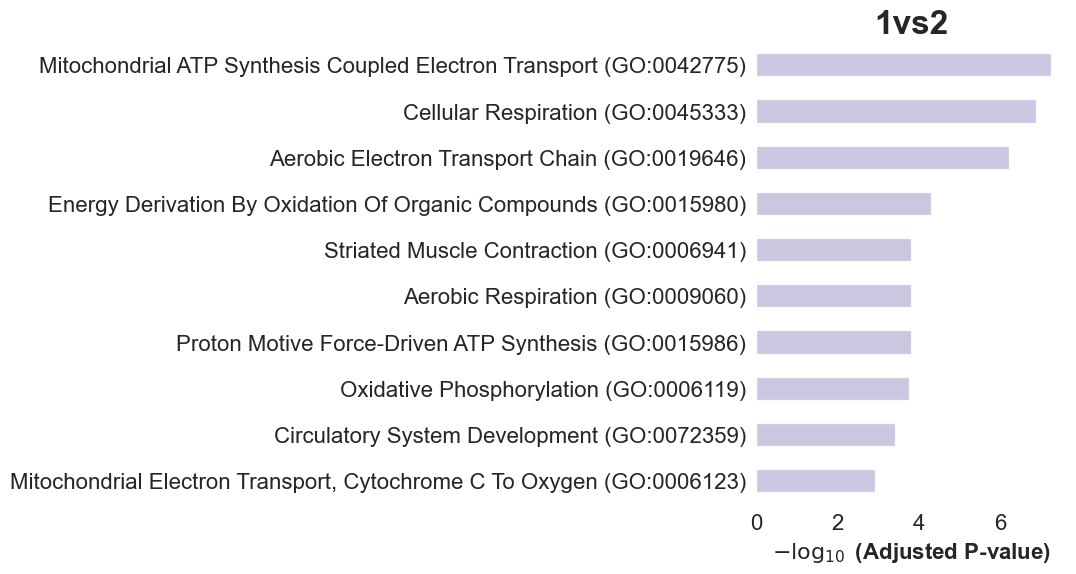

In [175]:
gseapy.barplot(enr_res1.res2d,title='1vs2',color='#b9b6d8')

In [23]:
plt.rcParams['axes.facecolor'] = 'white'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'white'  # 设置整张图的背景颜色

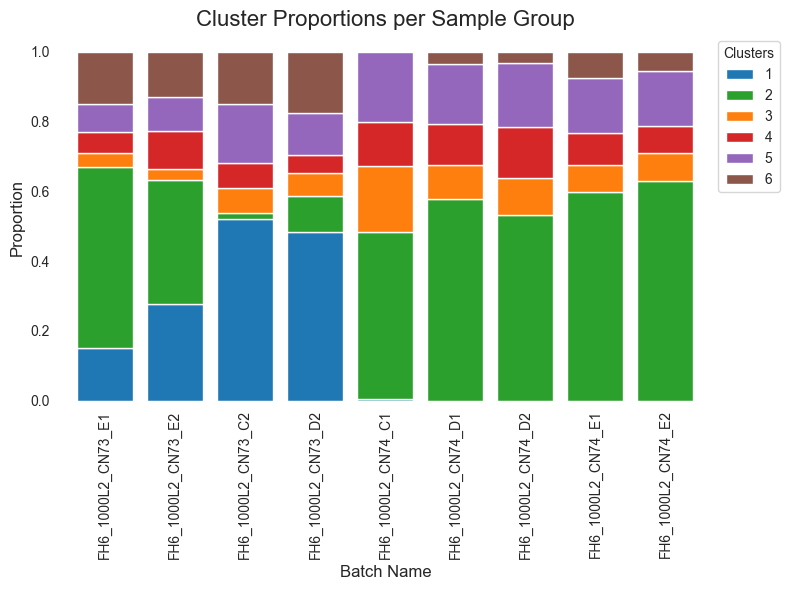

In [36]:
cluster_counts = adata.obs['mclust'].value_counts()

# 计算聚类比例
cluster_proportions = cluster_counts / cluster_counts.sum()

# 如果你有多个样本，假设每个样本的聚类标签为分类数据，进行聚类的比例汇总
# 可以按照样本进行统计（例如按某个特定变量或样本的ID列进行分组）

# 假设你希望按样本或者组别对比例进行堆叠柱状图展示：
# 你可以用 `pd.crosstab` 来查看每个聚类在不同样本中的分布

# 如果你有样本的组别信息，假设为 'sample_group'
# 示例：创建一个假的 sample_group 列（假设它已经存在于 adata.obs 中）

# 绘制堆叠柱状图
# 计算每个样本组别中每个聚类的比例
sample_groups = adata.obs['batch_name']  # 如果有这个列
cluster_by_group = pd.crosstab(sample_groups, adata.obs['mclust'], normalize='index')

# 找到每个 batch 中占比最大的聚类
max_clusters = cluster_by_group.idxmax(axis=1)
max_cluster_proportions = cluster_by_group.max(axis=1)

cluster_by_group = cluster_by_group.iloc[[2, 3, 0, 1] + list(range(4, len(cluster_by_group)))]  # 将第3和第4行移到第1和第2行后面

#15个颜色的调色板
custom_palette1 = {
    1: '#1f77b4',  
    2: '#ff7f0e',  
    3: '#2ca02c',  
    4: '#d62728',  
    5: '#9467bd',  
    6: '#8c564b',  
    7: '#e377c2',  
    8: '#7f7f7f',  
    9: '#bcbd22',  
    10: '#17becf'
}
#colors = ['#5c839f', '#946943', '#639763', '#8d5353', '#655573', '#8a736e', '#683e5b', '#707070', '#99995a', '#53959b', '#5c839f', '#f1d7a2', '#999999', '#8d5353', '#655573']

# 绘制堆叠柱状图
fig, ax = plt.subplots(figsize=(8, 6))
cluster_by_group.plot(kind='bar', stacked=True, ax=ax, width=0.8 ,color=custom_palette11)

# 设置标题和标签
ax.set_title('Cluster Proportions per Sample Group', fontsize=16)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_xlabel('Batch Name', fontsize=12)

# 显示图例
plt.legend(title="Clusters", loc='upper left', bbox_to_anchor=(1, 1))

# 显示图形
plt.tight_layout()
plt.show()

In [35]:
#adata.write('HH2.h5ad')

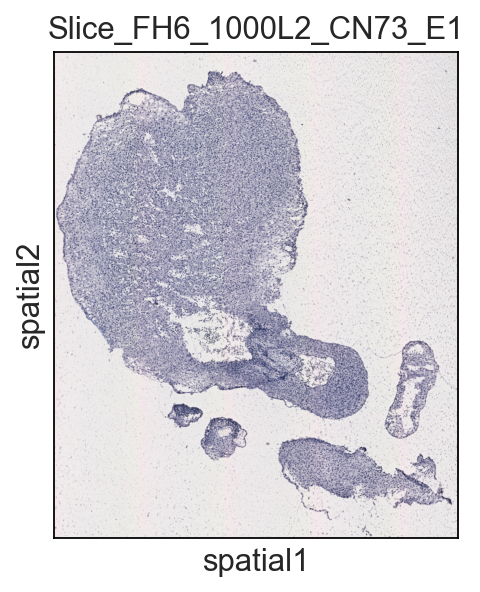

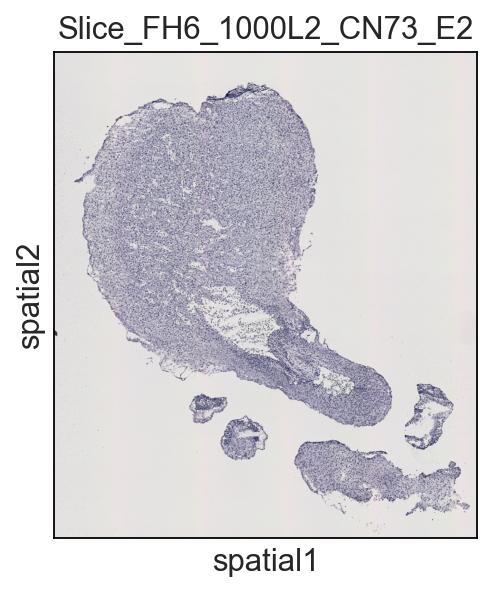

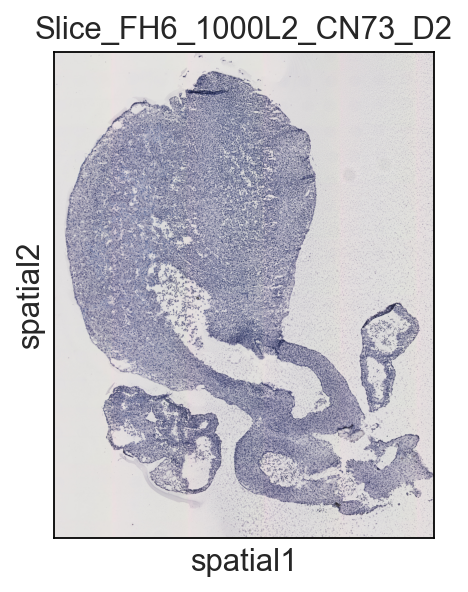

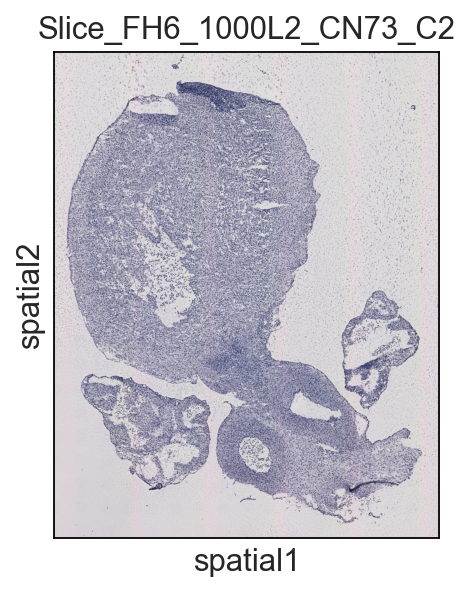

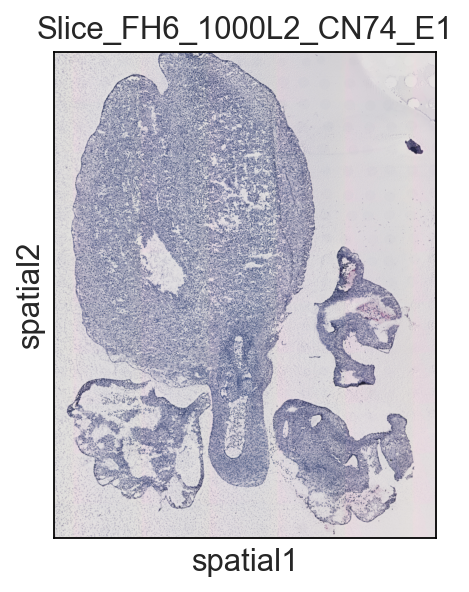

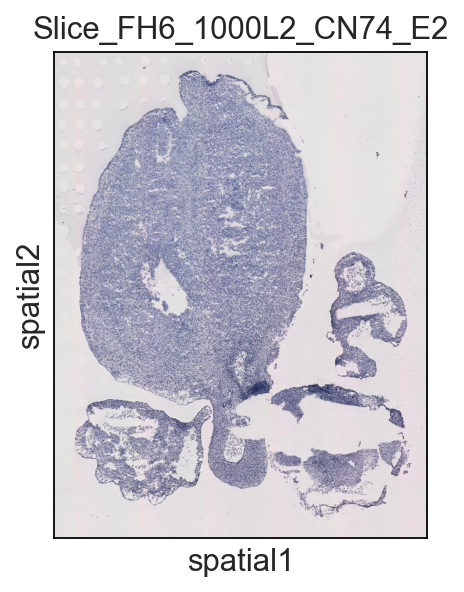

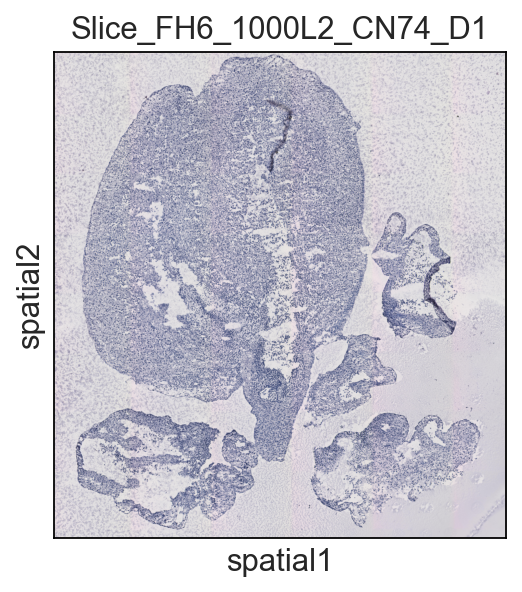

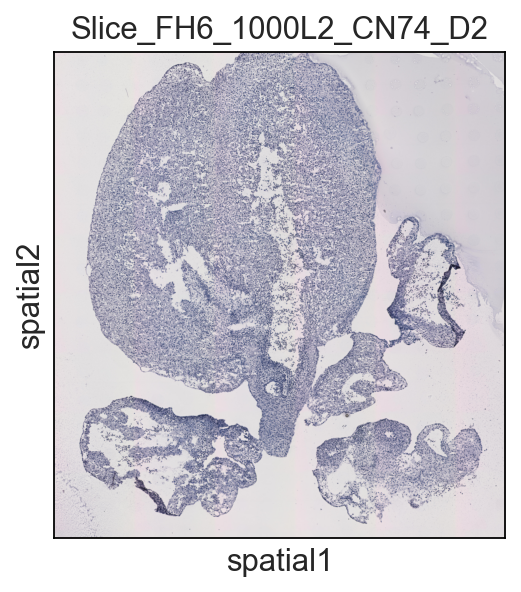

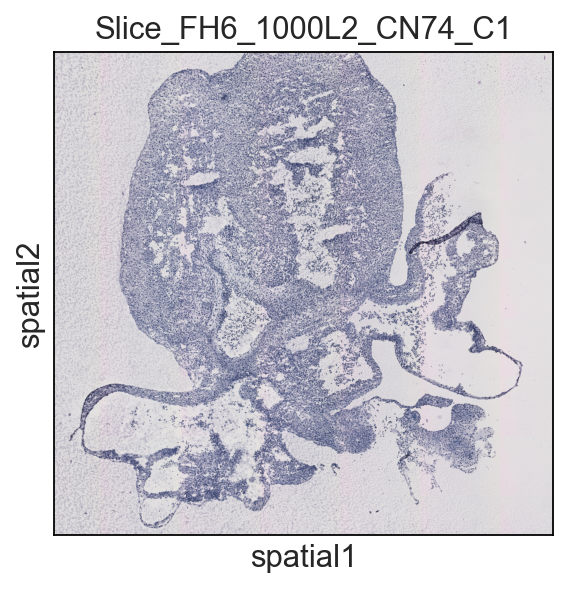

<Figure size 320x320 with 0 Axes>

In [36]:
# for slice_id, slice_name in enumerate(slice_use):
#     # print(slice_id)
#     # print(slice_name)
#     adata_st_list_raw_tmp = adata_st_list_raw[slice_id]
#     # print(adata_st_list_raw_tmp)
#     adata_tmp = adata[adata.obs['batch_name'] == slice_use[slice_id]]
#     adata_tmp.uns['spatial'] = adata_st_list_raw_tmp.uns['spatial']
#     # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
#     sc.pl.spatial(adata_tmp, img_key="hires", palette=custom_palette1, size=1.5, title=f"Slice_{slice_name}")
# plt.tight_layout()